In [1]:
# UCB ACQUISITION FUNCTION
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + (kappa * sigma)
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

In [2]:
import numpy as np
import pandas as pd

# Detect likely contamination sources in a two-dimensional area, such as a radiation field, 
# where only proximity yields a non-zero reading.
# The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

# Set random seed for reproducibility
np.random.seed(42)

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

# X_initial and y_initial should already exist from baseline points
X_initial = X.copy()
y_initial = y.copy()

X_weekly_list = []
y_weekly_list = []

# --- WEEKLY UPDATE SECTION ---
new_queries = [
    [0.828282, 0.777777], # Week 1
    [0.636363, 0.676767]  # Week 2
]
new_results = [
    -1.6268381341133806e-44, # Week 1
    -0.014642396013764629 # Week 2
]

# [0.828282, 0.777777]
# -1.6268381341133806e-44
# [0.636363, 0.676767]
# -0.014642396013764629

# Create the "Weekly Only" arrays for your Distance and Sensitivity plots
X_weekly = np.array(new_queries)
y_weekly = np.array(new_results)

# Reference for convenience
X_lastweek = X_weekly[-1]
y_lastweek = y_weekly[-1]

# Automatically update your main dataset
X = np.vstack([X_initial, new_queries])
y = np.append(y_initial, new_results)

print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)


df = pd.DataFrame(X, columns=["x1","x2"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)
df

# Week1 result now in 2nd from bottom
# week1_X = [0.828282, 0.777777]
# week1_y = 1.6268381341133806e-44
# 10	0.828282	0.777777	1.626838e-44 --week1
# 11	0.636363	0.676767	-1.464240e-02 --week2

-- inputs X ---
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.828282   0.777777  ]
 [0.636363   0.676767  ]]
X shape= (12, 2)
-- outputs y ---
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -1.62683813e-044 -1.46423960e-002]
y shape= (12,)


,x1,x2,y
2,0.731024,0.733000,7.710875e-16
7,0.683418,0.861057,2.535001e-40
1,0.574329,0.879898,1.033078e-46
9,0.883890,0.582254,6.229856e-48
0,0.319404,0.762959,1.322677e-79
8,0.082507,0.403488,3.606771e-81
3,0.840353,0.264732,3.341771e-124
6,0.312691,0.078723,-2.089093e-91
5,0.410437,0.147554,-2.159249e-54
10,0.828282,0.777777,-1.626838e-44


In [3]:
# # Week2
# # Data clean up
# # This is a error and it is masked
# # 0.650114	0.681526	-3.606063e-03
# size_limit = 1e-6
# mask = y > -size_limit

# X = X[mask]
# y = y[mask]

# # This two small negative are set to 0 - could be instrument measurement error
# # 3	0.410437	0.147554	-2.159249e-54
# # 4	0.650114	0.681526	-3.606063e-03

# y[y < 0] = 0.0
# eps = 1e-300   # far below any real signal
# y_log = np.log(y + eps)

# This is a error and it is masked
# 0.650114	0.681526	-3.606063e-03
pit_location = [0.650114, 0.681526]

# week3
# Instead of masking and zeroing:
# take symmetric log to handle large negative and zero and extreme scale
def symlog(y, threshold=1e-6):
    # within the threshold do linear scale
    # outside do log transform
    return np.where(np.abs(y) > threshold, 
                    np.sign(y) * np.log10(np.abs(y) / threshold), 
                    y / threshold)

y_log = symlog(y, threshold=1e-9)
y_initial_log = symlog(y_initial, threshold=1e-9)
y_weekly_log = symlog(y_weekly, threshold=1e-9)

sorted_idx = np.argsort(y)[::-1]
best_idx      = sorted_idx[0]
second_idx    = sorted_idx[1]
third_idx     = sorted_idx[2]

x_best  = X[best_idx]
x_second_best = X[second_idx]
x_third_best  = X[third_idx]

y_best        = y[best_idx]
y_second_best = y[second_idx]
y_third_best  = y[third_idx]

y_best_log = np.max(y_log)

print(sorted_idx)

print('----pit location--', pit_location)

print(f"Current Best x_idx: {best_idx}")
print(f"Current Best x: {x_best}")
print(f"Current Best y: {y_best}")
print(f"Current Best log_y: {y_best_log}")

print(f"Current 2nd Best x: {x_second_best}, y:{y_second_best}")
print(f"Current 3nd Best x: {x_third_best}, y:{y_third_best}")

print('-- outputs y ---')
print(y_log)
print("y shape=",y.shape)


df_log = pd.DataFrame(X, columns=["x1","x2"])
df_log['y'] = y_log
df_log = df_log.sort_values(by='y', ascending=False)
print(df_log)

[ 2  7  1  9  0  8  3  6  5 10  4 11]
----pit location-- [0.650114, 0.681526]
Current Best x_idx: 2
Current Best x: [0.73102363 0.73299988]
Current Best y: 7.710875114502849e-16
Current Best log_y: 7.710875114502849e-07
Current 2nd Best x: [0.68341817 0.86105746], y:2.5350011535584046e-40
Current 3nd Best x: [0.57432921 0.8798981 ], y:1.0330782375230975e-46
-- outputs y ---
[ 1.32267704e-070  1.03307824e-037  7.71087511e-007  3.34177101e-115
 -6.55703327e+000 -2.15924904e-045 -2.08909327e-082  2.53500115e-031
  3.60677119e-072  6.22985647e-039 -1.62683813e-035 -7.16561215e+000]
y shape= (12,)
          x1        x2              y
2   0.731024  0.733000   7.710875e-07
7   0.683418  0.861057   2.535001e-31
1   0.574329  0.879898   1.033078e-37
9   0.883890  0.582254   6.229856e-39
0   0.319404  0.762959   1.322677e-70
8   0.082507  0.403488   3.606771e-72
3   0.840353  0.264732  3.341771e-115
6   0.312691  0.078723  -2.089093e-82
5   0.410437  0.147554  -2.159249e-45
10  0.828282  0.7777

In [4]:
import numpy as np
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel, WhiteKernel
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
from scipy.stats import norm

warnings.filterwarnings('ignore', category=ConvergenceWarning)

# week1
# kernel = Matern(nu=2.5, length_scale_bounds=(0.1, 1.0))
# noise_assumption=1e-6
# gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, alpha=noise_assumption, n_restarts_optimizer=5)

# week2
kernel = (
    ConstantKernel(1.0, (1e-2, 1e2)) *   # signal variance
    Matern(
            length_scale=[0.15, 0.15],
            length_scale_bounds=(0.05, 0.25),
           nu=1.5) +
    WhiteKernel(noise_level=1e-4, noise_level_bounds="fixed")
)


gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gp.fit(X, y_log)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y_log)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

# Optimized Kernel: 0.764**2 * Matern(length_scale=[0.25, 0.25], nu=1.5) + WhiteKernel(noise_level=0.0001)
# Training R^2 Score: 0.9999999838286098
# Total variance accounted for as noise: 1e-10

# week3
# Optimized Kernel: 0.955**2 * Matern(length_scale=[0.0836, 0.0903], nu=1.5) + WhiteKernel(noise_level=0.0001)
# Training R^2 Score: 0.9999999828810495
# Total variance accounted for as noise: 1e-10


Optimized Kernel: 0.832**2 * Matern(length_scale=[0.0931, 0.05], nu=1.5) + WhiteKernel(noise_level=0.0001)
Training R^2 Score: 0.9999999716801973
Total variance accounted for as noise: 1e-10


In [5]:
# Create grid of potential X values
res=100
x_coord = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x_coord, x_coord)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T

# Get predictions
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)

rmse = np.sqrt(np.mean((mu - y_log)**2))
print("Log-space RMSE:", rmse)

Log-space RMSE: 2.6446756013847392


In [6]:
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)

ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"--- Optimization Results ---")
print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y_best}")
print(f"Suggested next: {ucb_next_query}")

--- Optimization Results ---
UCB Score with kappa: 2.0
Current Best y: 7.710875114502849e-16
Suggested next: [0.71717172 0.7979798 ]


In [7]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best_log, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"--- Optimization Results ---")
print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y_best}")
print(f"Suggested next: {ei_next_query}")

--- Optimization Results ---
expected_improvement with xi: 0.01
Current Best y: 7.710875114502849e-16
Suggested next: [0.74747475 0.76767677]


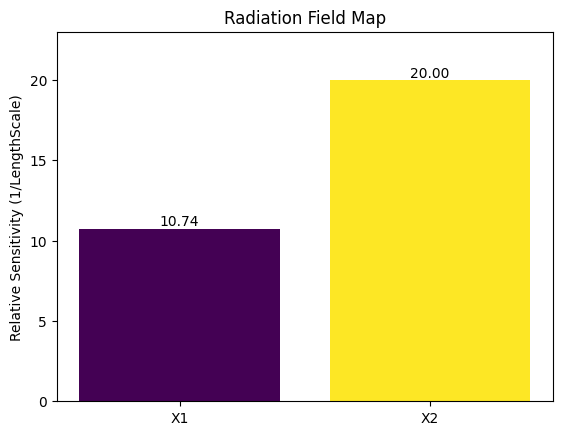

In [8]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# 1. Feature Sensitivity (Length Scales)
# We plot 1/Length_Scale because a higher value = higher importance
# lscales = gp.kernel_.k2.length_scale
lscales=np.array([0.0931, 0.05])
sensitivities = 1 / lscales
names = ['X1', 'X2']

# Create a colormap (e.g., 'viridis', 'plasma', or 'coolwarm') 
# and normalize it based on the sensitivity values
norm = Normalize(vmin=min(sensitivities), vmax=max(sensitivities))
colors = cm.viridis(norm(sensitivities))

# Create the bar plot using the 'colors' array
bars = plt.bar(names, sensitivities, color=colors)

# Create the bar plot and store the container in 'bars'
# bars = plt.bar(names, sensitivities, color='teal')
plt.ylabel('Relative Sensitivity (1/LengthScale)')
plt.title('Radiation Field Map')

# Annotate each bar with its value
for bar in bars:
    yval = bar.get_height()
    # We place the text at (x_center, y_top)
    # va='bottom' ensures the text sits just above the bar
    text_location = bar.get_x() + bar.get_width()/2
    plt.text(text_location, yval, f'{yval:.2f}', va='bottom', ha='center', fontsize=10)

# Adjust y-limit slightly to make room for the labels at the top
plt.ylim(0, max(sensitivities) * 1.15)

plt.show()

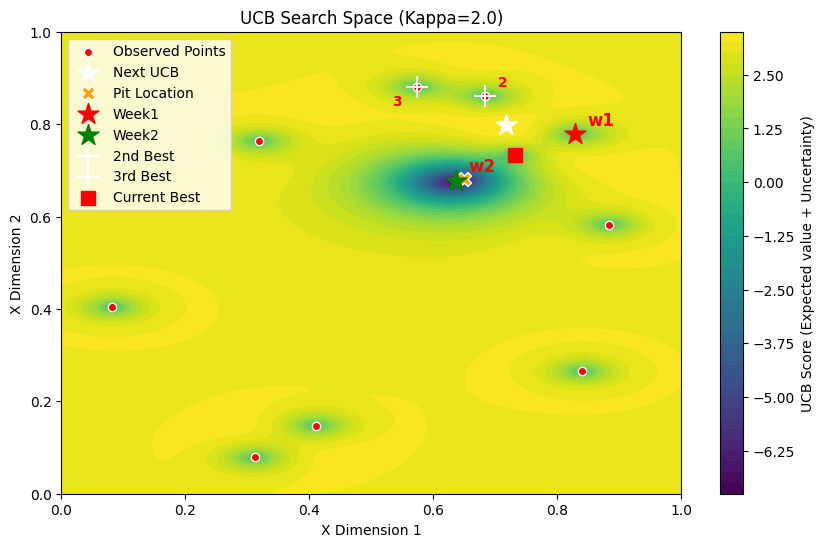

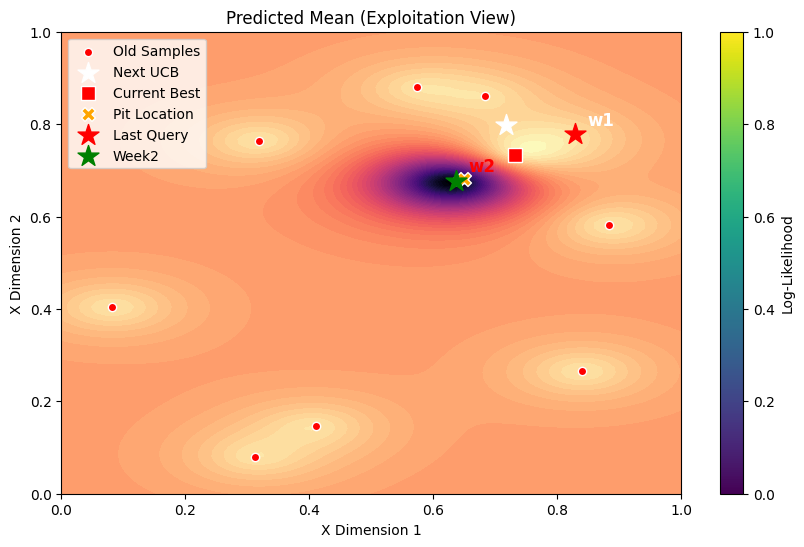

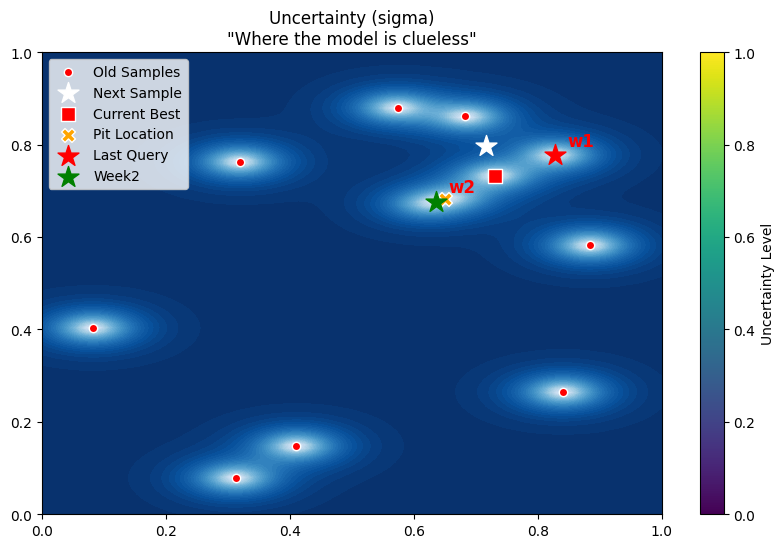

In [9]:
# UCB VISUALIZATION
ucb_map = ucb_values.reshape(res, res)
week1_query= X_weekly[0]
week2_query= X_weekly[1]

plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, ucb_map, levels=50, cmap='viridis')
plt.colorbar(label='UCB Score (Expected value + Uncertainty)')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next UCB')
plt.scatter(pit_location[0], pit_location[1], c='orange', edgecolors='white', marker='X', s=100, label='Pit Location')

plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Week1')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')

plt.scatter(week2_query[0], week2_query[1], c='green', marker='*', s=250, label='Week2')
plt.text(week2_query[0] + 0.02, week2_query[1] + 0.02, 'w2', fontsize=12, fontweight='bold', color='red')

plt.scatter(x_second_best[0], x_second_best[1], c='white', marker='+', s=250, label='2nd Best')
plt.text(x_second_best[0] + 0.02, x_second_best[1] + 0.02, '2', fontsize=10, fontweight='bold', color='red')

plt.scatter(x_third_best[0], x_third_best[1], c='white', marker='+', s=250, label='3rd Best')
plt.text(x_third_best[0] - 0.04, x_third_best[1] - 0.04, '3', fontsize=10, fontweight='bold', color='red')

plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', marker='s', s=100, label='Current Best')
plt.title(f"UCB Search Space (Kappa={kappa})")
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

mu_map = mu.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, mu_map, levels=50, cmap='magma')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Old Samples')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next UCB')
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')
plt.scatter(pit_location[0], pit_location[1], c='orange', edgecolors='white', marker='X', s=100, label='Pit Location')

plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='white')
plt.scatter(week2_query[0], week2_query[1], c='green', marker='*', s=250, label='Week2')
plt.text(week2_query[0] + 0.02, week2_query[1] + 0.02, 'w2', fontsize=12, fontweight='bold', color='red')

plt.title('Predicted Mean (Exploitation View)')
plt.colorbar(label='Log-Likelihood')
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

sigma_map = sigma.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, sigma_map, levels=50, cmap='Blues')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Old Samples')
plt.scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next Sample')
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')
plt.scatter(pit_location[0], pit_location[1], c='orange', edgecolors='white', marker='X', s=100, label='Pit Location')

plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')
plt.scatter(week2_query[0], week2_query[1], c='green', marker='*', s=250, label='Week2')
plt.text(week2_query[0] + 0.02, week2_query[1] + 0.02, 'w2', fontsize=12, fontweight='bold', color='red')


plt.title('Uncertainty (sigma)\n"Where the model is clueless"')
plt.colorbar(label='Uncertainty Level')
plt.legend()
plt.show()

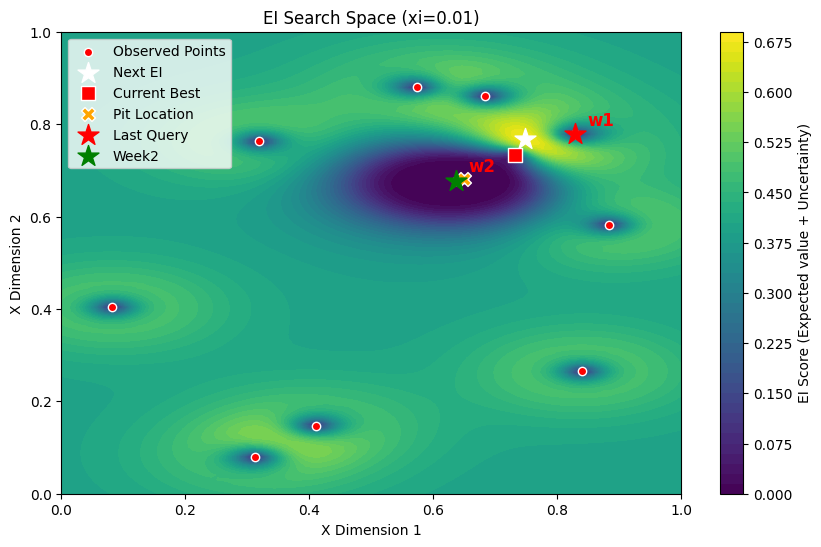

In [10]:
# EI VISUALIZATION
ei_map = ei_values.reshape(res, res)
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, ei_map, levels=50, cmap='viridis')
plt.colorbar(label='EI Score (Expected value + Uncertainty)')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
plt.scatter(ei_next_query[0], ei_next_query[1], c='white', marker='*', s=250, label='Next EI')
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', edgecolors='white', marker='s', s=100, label='Current Best')
plt.scatter(pit_location[0], pit_location[1], c='orange', edgecolors='white', marker='X', s=100, label='Pit Location')


plt.scatter(week1_query[0], week1_query[1], c='red', marker='*', s=250, label='Last Query')
plt.text(week1_query[0] + 0.02, week1_query[1] + 0.02, 'w1', fontsize=12, fontweight='bold', color='red')
plt.scatter(week2_query[0], week2_query[1], c='green', marker='*', s=250, label='Week2')
plt.text(week2_query[0] + 0.02, week2_query[1] + 0.02, 'w2', fontsize=12, fontweight='bold', color='red')

plt.title(f"EI Search Space (xi={xi})")
plt.xlabel("X Dimension 1")
plt.ylabel("X Dimension 2")
plt.legend()
plt.show()

In [11]:
# Observation
# --------Week2
# week1 result turns out be great and it is in the 3rd place 
# week1_X = [0.828282, 0.777777]
# week1_y = 1.6268381341133806e-44
# 10	0.828282	0.777777	1.626838e-44


# PIT removed
# This is a error and it is masked (Pit)
# 0.650114	0.681526	-3.606063e-03

# This two small negative are set to 0 - could be instrument measurement error
# 3	0.410437	0.147554	-2.159249e-54
# 4	0.650114	0.681526	-3.606063e-03

# - Pit removed
# - tiny negative reading turn to 0 (tiny positive for log to work)
# - run log of the y as the y is tiny and ranges are wide
# - run the BO
# - BO suggest both UCB/EI point next best query near to location where the pit was. EI is bit confident the best is on the Pit location
# week1 submission is 3rd best value so far

# I think EI is heading in the right direction, the pit was just a trap. 
# 
# Verdict: choose EI this week to verify the theory that pit is just a trap 

# --- Optimization Results --- 
# expected_improvement with xi: 0.01
# Current Best y: 7.710875114502849e-16
# Suggested next: [0.63636364 0.67676768]

# week1-> [0.828282, 0.777777] -> 1.6268381341133806e-44
# week2-> [0.636363, 0.676767] --> went to bottom
# week3-> [0.717171-0.797979]  -> climbing up the hill (symmetric log to take account of negative values)

# Note:-
# week2 - found a negative values near the pit and negative values are not just aberration, we need to take into account. 
# I have dont symlog instead of plain log to take into all the wide range of values

         

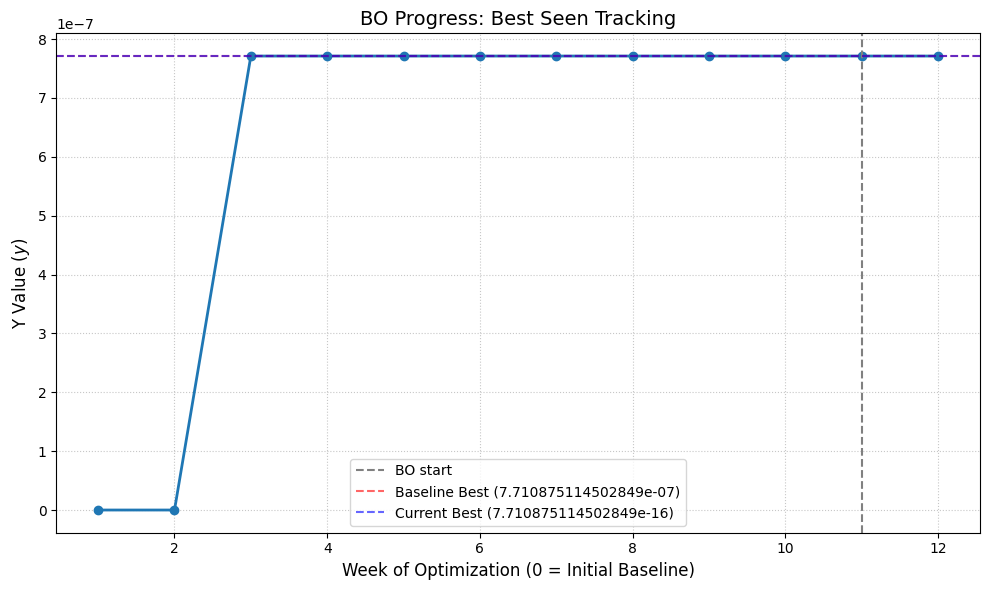

In [12]:
# Convergence Report
y_observed = y_log
baseline_best = np.max(y_initial_log)

weekly = np.arange(1, len(y_observed) + 1)
best_seen_trace = np.maximum.accumulate(y_observed)

bo_start_idx = 10  # zero-based index of first BO point

plt.figure(figsize=(10,6))
plt.plot(weekly, best_seen_trace, marker='o', linewidth=2)

# Vertical line separating phases
plt.axvline(x=bo_start_idx + 1, color='gray', linestyle='--', label='BO start')

# Plot the baseline best as a horizontal reference
plt.axhline(y=baseline_best, color='red', linestyle='--', alpha=0.6, label=f'Baseline Best ({baseline_best})')
plt.axhline(y=y_best_log, color='blue', linestyle='--', alpha=0.6, label=f'Current Best ({y_best})')

# Plot the individual weekly results
# plt.scatter(y_weekly_log[0:], y, color='black', zorder=3, label='Weekly Query Result ($y_t$)')

plt.title('BO Progress: Best Seen Tracking', fontsize=14)
plt.xlabel('Week of Optimization (0 = Initial Baseline)', fontsize=12)
plt.ylabel('Y Value ($y$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Highlight improvement
improvement = best_seen_trace[-1] - baseline_best
# if improvement > 0:
#     plt.annotate(f'Total Improvement: +{improvement:.2f}', 
#                  xy=(weekly[-1], best_seen_trace[-1]), 
#                  xytext=(weekly[-1]+2, best_seen_trace[-1] + 2),
#                  arrowprops=dict(facecolor='green', shrink=0.05))

plt.tight_layout()
plt.show()



In [13]:
# Metrics History
from scipy.spatial.distance import euclidean

ucb_next_query_dist = euclidean(ucb_next_query, x_best)
ei_next_query_dist = euclidean(ei_next_query, x_best)

print(f"Distance from Best X, ucb_next_query_dist:{ucb_next_query_dist}")
print(f"Distance from Best X, ei_next_query_dist:{ei_next_query_dist}")

# Calculate prediction Error
x_next = ucb_next_query

y_pred, sigma = gp.predict(x_next.reshape(1, -1), return_std=True)
confidence_value = sigma[0]

print(f"======== NextQuery==========") 
print(f"Query:{x_next}")
print(f"Model Confidence (σ): {confidence_value:.4f}")
print(f"Model Predicted: {y_pred[0]:.2f}")

## fill in weekly
# y_actual = -1.6268381341133806e-44
# prediction_error = np.abs(y_pred[0] - y_actual)
# print(f"Actual Result:  {y_actual:.2f}")
# print(f"Prediction Error: {prediction_error:.2f}")
print(f"Distance:{euclidean(x_next, x_best)}")

print("==================") 
print("Weekly Queries:") 
for i, (query, result) in enumerate(zip(new_queries, new_results), start=1):
    print(f"Week: {i} | Query: {query} | Result: {result:.8e}")

print("==================") 
print("Next Week Query: UCB")
print(ucb_next_query)

# new_queries = [
#     [0.828282, 0.777777], # Week 1
#     [0.636363, 0.676767]  # Week 2
# ]
# new_results = [
#     -1.6268381341133806e-44, # Week 1
#     -0.014642396013764629 # Week 2
# ]

Distance from Best X, ucb_next_query_dist:0.06643994071366188
Distance from Best X, ei_next_query_dist:0.03838132387328912
======== NextQuery==========
Query:[0.71717172 0.7979798 ]
Model Confidence (σ): 1.8132
Model Predicted: -0.17
Distance:0.06643994071366188
Weekly Queries:
Week: 1 | Query: [0.828282, 0.777777] | Result: -1.62683813e-44
Week: 2 | Query: [0.636363, 0.676767] | Result: -1.46423960e-02
Next Week Query: UCB
[0.71717172 0.7979798 ]
